# A First Tutorial for Pytorch

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

## 1. Understanding Gradient Computations

Tensor --> data structure that enables gradient recordings

Pytorch keeps a computational graph that maintains the operation’s gradient function.

When the gradient is required, it computes the gradients from each .grad_fn attribute, accumulates them in the respective tensor’s .grad attribute, and propagates using the chain rule.

**Example 1:** $f: \mathbb{R} \rightarrow \mathbb{R}$. Compute $f'(x)$ at a point $x$.

In [2]:
x = torch.tensor(3.0,requires_grad = True)

# Compute the cube
y = x ** 3

# Auto differentiation, get the gradient of y w.r.t. x, return value is tuple of tensors
# create graph shows reduces the time it takes to compute higher order derivatives
'''
When calling autograd.grad, the first argument must be a scalar!
'''
y_prime = torch.autograd.grad(y,x,create_graph = True)[0]

In [3]:
# x^3 has derivative 3x^2, evaluated at x = 3, the result shall be 27
print(y_prime)

tensor(27., grad_fn=<MulBackward0>)


**Example 2:** $f: \mathbb{R^n} \rightarrow \mathbb{R}$. Compute $\nabla f(x)$ at a point $x \in \mathbb{R}^n$.

In [4]:
x = torch.tensor([3., 2., 1.],requires_grad = True)

# y = (x0)^2 + 2 * x0 * x1 + (x1)^2 - 7 * x_2
y = x[0] ** 2 + 2 * x[0] * x[1] + x[1] ** 2 - 7 * x[2]

# Gradient at x = [3,2,1]
y_grad = torch.autograd.grad(y,x,create_graph = True)[0]

In [5]:
# Gradient shall be [2 * x0 + 2 * x1, 2 * x0 + 2 * x1, -7], evaluated at x = [3,2,1],
# the result shall be [10, 10, -7]
print(y_grad)

tensor([10., 10., -7.], grad_fn=<AddBackward0>)


**Example 3:** $f: \mathbb{R} \rightarrow \mathbb{R}$. Compute $f'(x)$ at multiple points $x_1,...,x_n$.

The easy implementation makes use of the following fact: consider $g:\mathbb{R}^n\to\mathbb{R}$ such that $g(u) = \sum_{i=1}^nf(u_i)$, then
$$\frac{\partial g}{\partial u_i}(x) = f'(x_i),\text{where}\ x = (x_1,...,x_n)^T.$$

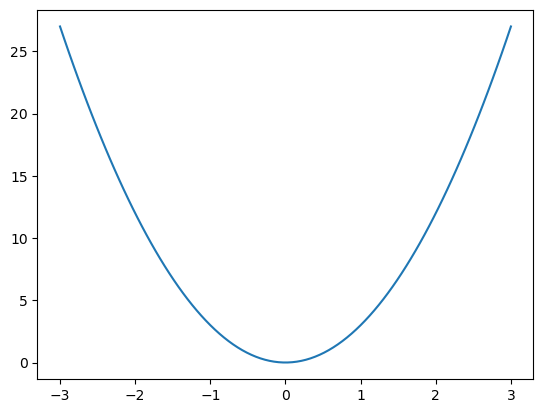

In [6]:
x = torch.linspace(-3,3,100)
x.requires_grad = True

# Component-wise cube
y = x ** 3

# sum(y) is a scalar, allowed
y_prime = torch.autograd.grad(sum(y),x,create_graph = True)[0]

# Detach the gradient off the tensor to make it an array for plotting
# The curve is (x^3)' = 3x^2
plt.plot(x.detach(),y_prime.detach())

**Example 4:** $f: \mathbb{R} \rightarrow \mathbb{R}$. Compute $f''(x)$ at $x$.

In [7]:
x = torch.tensor(3.0,requires_grad = True)
y = x ** 3
y_prime = torch.autograd.grad(y,x,create_graph = True)[0]
y_prime_prime = torch.autograd.grad(y_prime,x,create_graph = True)[0]

In [8]:
# (x^3)'' = 6x, evaluated at x = 3, the result should be 18
print(y_prime_prime)

tensor(18., grad_fn=<MulBackward0>)


**Example 5:** $f: \mathbb{R} \rightarrow \mathbb{R}$. Compute $f''(x)$ at multiple points $x_1,...,x_n$. **Left as an exercise.**

**Example 6:** $f: \mathbb{R^n} \rightarrow \mathbb{R}$. Compute $\nabla^2 f(x)$ at a point $x \in \mathbb{R}^n$.

In [9]:
x = torch.tensor([3., 2., 1.],requires_grad = True)

# y = e^(x0) + 2 * x0 * x1 + (x1)^2 - 7 * x_2
'''
Good habit to use torch built-in functions instead of numpy versions
'''
y = torch.exp(x[0]) + 2 * x[0] * x[1] + x[1] ** 2 - 7 * x[2]

# Gradient at x = [3,2,1]
y_grad = torch.autograd.grad(y,x,create_graph = True)[0]

'''
y_grad is a vector! Cannot call grad directly on y!
Deal with each component instead.
'''
y_Hessian_rows = [torch.autograd.grad(y_grad[i],x,create_graph = True)[0] for i in range(3)]
y_Hessian = torch.stack(y_Hessian_rows)

In [10]:
# Hessian shall be:
# [[e^(x0), 2, 0],
#  [2,      2, 0],
#  [0,      0, 0]]
# evaluated at x = [3,2,1]
print(y_Hessian)

tensor([[20.0855,  2.0000,  0.0000],
        [ 2.0000,  2.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000]], grad_fn=<StackBackward0>)


## 2. Setting up Neural Network Architectures

In [11]:
from torch import nn

In [12]:
# NN with 2 layers and tanh activation
class l2tanh(nn.Module):
    def __init__(self,in_dim,out_dim):
        super().__init__()
        # Linear layers x -> Wx + b, specify input and output dimensions
        '''
        Support batched training!
        '''
        self.layer1 = nn.Linear(in_dim, 32)
        self.layer2 = nn.Linear(32, out_dim)

        # Activation
        self.activation = nn.Tanh()
    # Forward propagation rule
    def forward(self,x):
        z = self.layer1(x)
        z = self.activation(z)
        z = self.layer2(z)
        return z

In [13]:
# An instance of NN from the class
NN = l2tanh(in_dim = 2,out_dim = 1)

In [14]:
# Check the components
print(NN.layer1)
print(NN.layer2)
print(NN.activation)

Linear(in_features=2, out_features=32, bias=True)
Linear(in_features=32, out_features=1, bias=True)
Tanh()


In [15]:
# Check dimension of weight/bias
print(NN.layer1.weight)
print(NN.layer1.bias)

Parameter containing:
tensor([[-3.5884e-01,  3.4528e-01],
        [-6.9173e-01,  5.9874e-01],
        [ 1.9581e-01,  5.0014e-04],
        [ 1.6199e-01,  3.6710e-01],
        [-5.2213e-01,  2.5734e-01],
        [-6.9977e-01,  5.7184e-01],
        [ 4.3886e-01, -1.7268e-01],
        [-2.8392e-01, -2.1227e-01],
        [ 4.5414e-01, -5.0777e-01],
        [ 1.2690e-01, -3.6149e-01],
        [ 4.8118e-01, -5.7000e-01],
        [-6.7962e-01, -5.7411e-01],
        [-1.5973e-01,  1.1261e-01],
        [-3.5402e-01, -6.8046e-01],
        [ 6.9220e-01, -1.0970e-01],
        [ 2.7470e-01,  6.2173e-01],
        [ 5.9050e-01, -5.8830e-01],
        [ 4.6174e-01, -6.5004e-01],
        [ 5.4168e-01,  4.9951e-01],
        [-1.8735e-01,  6.7677e-01],
        [-9.4955e-02,  3.7497e-02],
        [-1.7473e-01,  1.6232e-01],
        [-4.6505e-01,  6.9115e-01],
        [-7.0636e-01,  1.9188e-01],
        [ 5.1209e-01, -3.0942e-01],
        [ 1.5711e-01,  5.7221e-01],
        [ 1.7872e-01, -1.1679e-01],
      

In [16]:
print(NN.layer2.weight)
print(NN.layer2.bias)

Parameter containing:
tensor([[ 0.1090,  0.0067,  0.0746, -0.1301,  0.1077,  0.0133,  0.0106, -0.0862,
          0.1559, -0.1717, -0.0226, -0.0038, -0.1501,  0.0594,  0.0152, -0.0654,
          0.0209,  0.1130,  0.1415,  0.0201, -0.0273,  0.1155,  0.1285,  0.1109,
         -0.0796, -0.0618, -0.0989, -0.1723, -0.0290,  0.1363,  0.0529, -0.1399]],
       requires_grad=True)
Parameter containing:
tensor([0.0571], requires_grad=True)


**Example 1**: Code the architecture of a 2-layer ResNet with Sigmoid activation. **Left as an exercise**.

## 3. Training Neural Networks

Training consists of loss (computed from forward propagation), autograd (provides the gradient) and optimizer (updates the parameters).
Let's say our objective is to enable the NN to perform multiplication, i.e., learning the mapping $(x,y)\mapsto xy$.
The neural network architecture stated above aligns with the dimension of this mapping $[0,1]^2\to\mathbb{R}$.

In [17]:
# A function for NN evaluation
def evaluate(NN):
    # Fix y and change x
    y = np.random.rand()
    x = torch.linspace(0,1,1000)
    samples = torch.stack([x,y * torch.ones(1000)],dim = 1)
    
    # Forward propagation
    NN_pred = NN(samples).squeeze()
    
    # True results
    true_pred = x * y
    
    plt.plot(x,true_pred,label = 'True')
    plt.plot(x,NN_pred.detach(),label = 'NN')
    plt.title('NN Performance when y=' + str(np.round(y,2)))
    plt.legend()

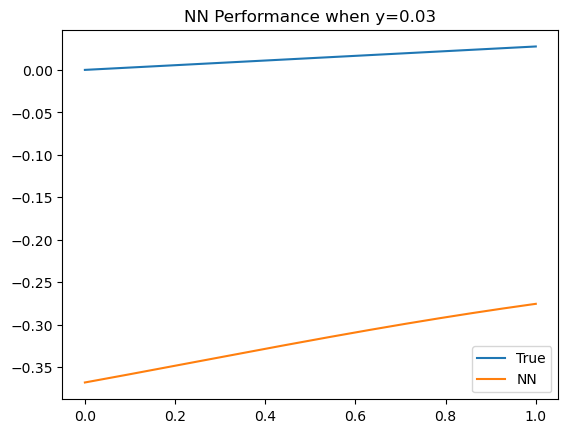

In [18]:
# Check NN performance
NN = l2tanh(in_dim = 2,out_dim = 1)
evaluate(NN)

Clearly, the NN approximation is far from a correct one before training takes place.

In [19]:
'''
SGD, Adam are popular choices
'''
# An optimizer
opt = torch.optim.Adam(NN.parameters(),lr = 0.1)

In [20]:
# Hyperparameters
N_EPOCH = 1000
N_BATCH = 128

for ind_epoch in range(N_EPOCH):
    # Randomly sample points to evaluate
    x = torch.rand(N_BATCH)
    y = torch.rand(N_BATCH)
    
    '''
    Input of NN: 2d tensor, rownum = batch size, colnum = input_dim of NN
    '''
    samples = torch.stack([x,y],dim = 1)
    
    '''
    Output of NN: 2d tensor, rownum = batch size, colnum = output_dim of NN
    '''
    NN_pred = NN(samples)
    
    # True product (1d tensor)
    true_pred = samples[:,0] * samples[:,1]
    
    # Reshape into a 1d tensor
    NN_pred_1d = torch.squeeze(NN_pred)

    '''
    Keep the dimensions consistent!!! Most bugs come from here!!!
    '''
    
    # Average square loss among the batch
    loss = torch.sum((NN_pred_1d - true_pred) ** 2) / (2 * N_BATCH)
    
    # Zero out the gradients before gradient calculations
    opt.zero_grad()
    
    '''
    Keep in mind to zero out the gradients!!! o.w. it accumulates!!!
    '''
    
    # Back propagation
    loss.backward()
    
    # Update parameters
    opt.step()
    
    # Verbose
    if (ind_epoch + 1) % 50 == 0:
        print('Loss: ' + str(loss.detach()))

Loss: tensor(0.0039)
Loss: tensor(0.0029)
Loss: tensor(0.0022)
Loss: tensor(0.0025)
Loss: tensor(0.0009)
Loss: tensor(0.0009)
Loss: tensor(0.0008)
Loss: tensor(0.0004)
Loss: tensor(0.0001)
Loss: tensor(6.4069e-05)
Loss: tensor(1.2982e-05)
Loss: tensor(2.1497e-05)
Loss: tensor(1.1670e-05)
Loss: tensor(1.5978e-05)
Loss: tensor(1.6598e-05)
Loss: tensor(1.0593e-05)
Loss: tensor(1.7626e-05)
Loss: tensor(1.0765e-05)
Loss: tensor(4.4320e-05)
Loss: tensor(1.0308e-05)


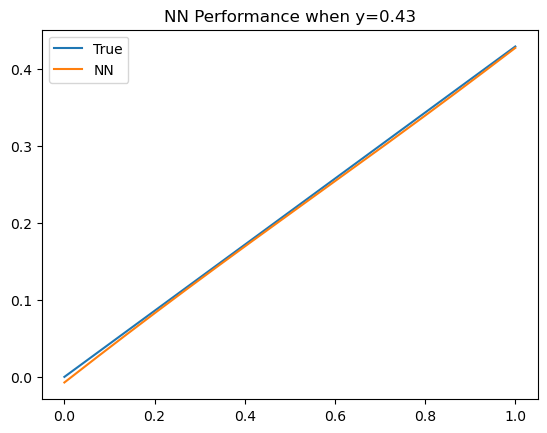

In [21]:
# Check the performance (run it multiple times, each time the 'y' is different)
evaluate(NN)

The neural network performs quite well on $[0,1]^2$. What about extrapolation tasks, i.e., when $(x,y)$ is outside $[0,1]^2$?

In [22]:
# Failures in out-of-sample predictions
x = 1.5
y = -0.2
sample = torch.tensor([[x,y]])
NN_pred = NN(sample)
print(NN_pred.detach())

tensor([[0.0099]])


Here's what you can play with this example to gain a better understanding in deep learning:
1. Test different number of epochs and batch sizes, how does that change the NN performance?
2. Test different initial learning rates (try $lr = 0.001$ and $lr = 1.0$ in the optimizer), what do you observe?
3. Change the uniform sampling of training samples to other distributions, e.g., a Gaussian, what do you observe?

Try to train an NN that approximates the mapping $f:\mathbb{R}^n\to\mathbb{R}$ such that $f(x) = \log\sum_{i=1}^n e^{x_i}$. **Left as an exercise**.

## 4. Applications

Solving a second-order ODE via physically-informed neural network (PINN). On $t\in[0,1]$, the ODE is provided by:

$$y''(t) + 2y'(t) + y(t) = 0, \quad y(0) = 0, \quad y'(0) = 1.$$
The true solution is $y(t) = te^{-t}$.

PINN idea: approximate the solution by a neural network $\phi(t)$ and form the loss by enforcing the ODE and the boundary conditions to hold:

$$\text{loss} = \int_0^1(\phi''(t) + 2\phi'(t) + \phi(t))^2 dt +  \lambda_1(\phi(0) - 0)^2 +  \lambda_2(\phi'(0) - 1)^2,$$
where the integral is approximated by a discretized sum and $\lambda_1,\lambda_2>0$ are regularization levels.

In [23]:
# NN
phi_NN = l2tanh(in_dim = 1,out_dim = 1)

# Optimizer
opt = torch.optim.Adam(phi_NN.parameters(),lr = 0.005)

In [24]:
# Hyperparameters
N_EPOCH = 1000
N_STEPS = 128 # Time discretization level
dt = 1.0 / N_STEPS
lamb1 = 10.0
lamb2 = 10.0

# 2d tensor, evaluate y at those points
t = torch.linspace(0,1,N_STEPS).unsqueeze(1)
t.requires_grad = True

for ind_epoch in range(N_EPOCH):
    # Forward propagation
    phi_pred = phi_NN(t)

    # phi'(t) at multiple points from autograd
    phi_pred_prime = torch.autograd.grad(sum(phi_pred),t,create_graph = True)[0]
    
    # phi''(t) at multiple points
    phi_pred_prime_prime = torch.autograd.grad(sum(phi_pred_prime),t,create_graph = True)[0]
    
    # Discretized integral value, ODE L2 loss
    ODEloss = torch.sum((phi_pred_prime_prime + 2 * phi_pred_prime + phi_pred) ** 2) * dt
    
    # Initial condition loss
    ICloss = lamb1 * (phi_pred[0] ** 2) + lamb2 * ((phi_pred_prime[0] - 1) ** 2)
    
    loss = ODEloss + ICloss
    
    # Zero out gradients
    opt.zero_grad()
    
    # Back propagation
    loss.backward()
    
    # Update parameters
    opt.step()
    
    # Verbose
    if (ind_epoch + 1) % 50 == 0:
        print('Loss: ' + str(loss.detach()))

Loss: tensor([0.0863])
Loss: tensor([0.0236])
Loss: tensor([0.0177])
Loss: tensor([0.0132])
Loss: tensor([0.0088])
Loss: tensor([0.0046])
Loss: tensor([0.0016])
Loss: tensor([0.0005])
Loss: tensor([0.0003])
Loss: tensor([0.0003])
Loss: tensor([0.0002])
Loss: tensor([0.0002])
Loss: tensor([0.0002])
Loss: tensor([0.0002])
Loss: tensor([0.0002])
Loss: tensor([0.0002])
Loss: tensor([0.0002])
Loss: tensor([0.0002])
Loss: tensor([0.0002])
Loss: tensor([0.0002])


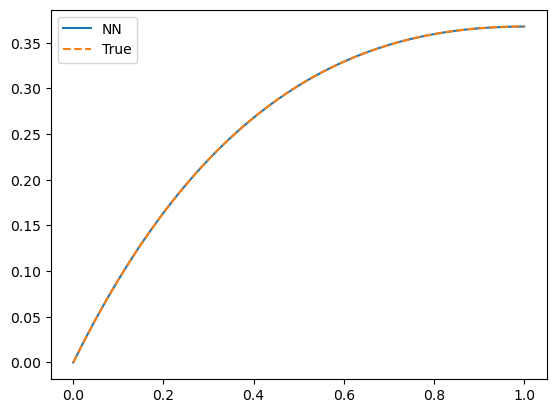

In [25]:
# Check the performance
plt.plot(t.detach(),phi_pred.detach(),label = 'NN')
plt.plot(t.detach(),(t * torch.exp(-t)).detach(),linestyle = '--',label = 'True')
plt.legend()

Here's what you can play with this example to gain a better understanding in DL-based PDE solvers:
1. Test different number of epochs and time discretization schemes, how does that change the NN performance?
2. Test different initial learning rates (try $lr = 0.0001$ and $lr = 1.0$ in the optimizer), what do you observe?
3. Change the regularization intensities $\lambda_1,\lambda_2$, (try $0.001$ and $100$) how does that affect the training result?

When it comes to numerically solving general PDEs in the control literature, the procedure is basically the same.

## 5. Answer to Exercise

Answer to example 1.5:

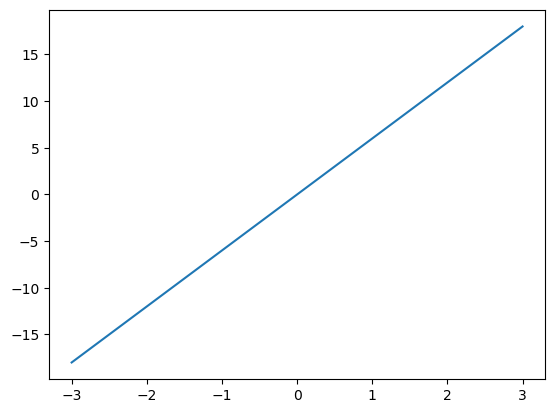

In [26]:
x = torch.linspace(-3,3,100)
x.requires_grad = True

# Component-wise cube
y = x ** 3

# sum(y) is a scalar, allowed
y_prime = torch.autograd.grad(sum(y),x,create_graph = True)[0]

# sum(y_prime) is a scalar, allowed
y_prime_prime = torch.autograd.grad(sum(y_prime),x,create_graph = True)[0]

# Detach the gradient off the tensor to make it an array for plotting
# The curve is (x^3)'' = 6x
plt.plot(x.detach(),y_prime_prime.detach())

Answer to example 2.1:

In [27]:
# Code for a ResNet
class l2Sigmoid_resnet(nn.Module):
    def __init__(self,in_dim,out_dim):
        super().__init__()
        self.layer1 = nn.Linear(in_dim, 32)
        self.layer2 = nn.Linear(32, out_dim)
        self.activation = nn.Sigmoid()

    # Forward propagation
    def forward(self,x):
        z = self.layer1(x)
        
        '''
        Key to ResNet architecture: skip connection
        '''
        z = self.activation(z) + z
        
        z = self.layer2(z)
        return z